In [1]:
import numpy as np
import math
import cv2
import json
import os
import glob
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec 
from skimage.morphology import skeletonize
from skimage import io


In [2]:
class ArteryGraphGenerator:
    def __init__(self, image_path):
        self.image_path = image_path
        self.image = None
        self.skeleton = None
        self.nodes = []
        self.edges = []
        self.extreme_nodes = []
        self.bifurcation_nodes = []
        self.trifurcation_nodes = []
        self.intermediate_nodes = []
        self.junction_map = None

    def load_image(self):
        """Load and preprocess the image."""
        # Check if the image is in PGM format
        if self.image_path.lower().endswith('.pgm'):
            self.image = cv2.imread(self.image_path, cv2.IMREAD_GRAYSCALE)
        else:
            self.image = cv2.imread(self.image_path)
            if len(self.image.shape) == 3:
                self.image = cv2.cvtColor(self.image, cv2.COLOR_BGR2GRAY)

        # Ensure the image is binary (0 for background, 255 for foreground)
        _, self.image = cv2.threshold(self.image, 127, 255, cv2.THRESH_BINARY)
        return self.image

    def create_skeleton(self):
        """Create a skeleton from the binary image."""
        if self.image is None:
            self.load_image()

        # Convert to proper format for skeletonize (0-1)
        binary_image = self.image / 255
        self.skeleton = skeletonize(binary_image)
        self.skeleton = (self.skeleton * 255).astype(np.uint8)
        return self.skeleton

    def analyze_connectivity(self):
        """Create a junction map to identify node types accurately."""
        if self.skeleton is None:
            self.create_skeleton()

        # Create a junction map
        self.junction_map = np.zeros_like(self.skeleton)

        # Identify junctions by counting neighbors
        for i in range(1, self.skeleton.shape[0]-1):
            for j in range(1, self.skeleton.shape[1]-1):
                if self.skeleton[i, j] > 0:
                    # Get 3x3 neighborhood
                    neighborhood = self.skeleton[i-1:i+2, j-1:j+2].copy()
                    neighborhood[1, 1] = 0  # Remove center pixel

                    # Count neighbors (non-zero pixels)
                    neighbor_count = np.count_nonzero(neighborhood)

                    if neighbor_count == 1:
                        # End point
                        self.junction_map[i, j] = 1
                    elif neighbor_count == 2:
                        # Check if it's a continuous line or a corner
                        # For a continuous line, pixels are on opposite sides
                        # For a corner, adjacent pixels are neighbors
                        if self._is_corner(neighborhood):
                            # This is a more complex case - consider it an intermediate node
                            self.junction_map[i, j] = 2
                        else:
                            # Continuous line
                            self.junction_map[i, j] = 2
                    elif neighbor_count == 3:
                        # Bifurcation
                        self.junction_map[i, j] = 3
                    elif neighbor_count > 4:
                        # Trifurcation or more complex junction
                        self.junction_map[i, j] = 4

        return self.junction_map

    def _is_corner(self, neighborhood):
        """Check if a neighborhood represents a corner rather than a straight line."""
        # This is a simplified approach. A more sophisticated approach would analyze
        # the pattern of neighbors to distinguish true corners
        positions = np.where(neighborhood > 0)
        if len(positions[0]) != 2:
            return False

        # Check if the two points are adjacent or on opposite sides
        r1, c1 = positions[0][0], positions[1][0]
        r2, c2 = positions[0][1], positions[1][1]

        # If they're on opposite sides, it's likely a straight line
        if (r1 == r2 and abs(c1 - c2) == 2) or (c1 == c2 and abs(r1 - r2) == 2):
            return False
        return True

    def identify_key_nodes(self):
        """Identify key nodes (extreme, bifurcation, trifurcation)."""
        if self.junction_map is None:
            self.analyze_connectivity()

        # Clear previous results
        self.extreme_nodes = []
        self.bifurcation_nodes = []
        self.trifurcation_nodes = []

        # Find extreme nodes (endpoints)
        extreme_points = np.where(self.junction_map == 1)
        for i in range(len(extreme_points[0])):
            row, col = extreme_points[0][i], extreme_points[1][i]
            self.extreme_nodes.append((row, col))

        # Find bifurcation nodes
        bifurcation_points = np.where(self.junction_map == 3)
        for i in range(len(bifurcation_points[0])):
            row, col = bifurcation_points[0][i], bifurcation_points[1][i]
            self.bifurcation_nodes.append((row, col))

        # Find trifurcation nodes (or more complex junctions)
        trifurcation_points = np.where(self.junction_map == 4)
        for i in range(len(trifurcation_points[0])):
            row, col = trifurcation_points[0][i], trifurcation_points[1][i]
            self.trifurcation_nodes.append((row, col))

        # Create a combined list of key nodes
        key_nodes = []
        for row, col in self.extreme_nodes:
            key_nodes.append({
                "type": "extreme",
                "coordinates": [int(row), int(col)]
            })

        for row, col in self.bifurcation_nodes:
            key_nodes.append({
                "type": "bifurcation",
                "coordinates": [int(row), int(col)]
            })

        for row, col in self.trifurcation_nodes:
            key_nodes.append({
                "type": "trifurcation",
                "coordinates": [int(row), int(col)]
            })

        # Assign IDs to key nodes
        for i, node in enumerate(key_nodes):
            node["id"] = i

        return key_nodes

    def _get_neighbors(self, row, col):
        """Get the neighboring pixels of a specific point in the skeleton."""
        neighbors = []

        # Check 8-connectivity
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue

                nr, nc = row + dr, col + dc
                if (0 <= nr < self.skeleton.shape[0] and
                        0 <= nc < self.skeleton.shape[1] and
                        self.skeleton[nr, nc] > 0):
                    neighbors.append((nr, nc))

        return neighbors

    def generate_graph_with_dfs(self, intermediate_node_spacing=5):
        """
        Generate the complete graph structure using DFS to find paths between key nodes.

        Parameters:
        intermediate_node_spacing (int): Approximate spacing between intermediate nodes

        Returns:
        dict: A dictionary containing the graph structure
        """
        # Identify key nodes
        key_nodes = self.identify_key_nodes()
        # print(f"Found {len(key_nodes)} key nodes")

        # Create a list of all key node coordinates for quick lookup
        key_coords = {}
        for node in key_nodes:
            coords = tuple(node["coordinates"])
            key_coords[coords] = node["id"]

        # Find extreme nodes for path starting points
        extreme_coords = [tuple(node["coordinates"]) for node in key_nodes if node["type"] == "extreme"]

        # Create a visited map to track explored paths
        visited = np.zeros_like(self.skeleton, dtype=bool)

        # Store for vessel segments
        vessel_segments = []

        # Store for intermediate nodes
        self.intermediate_nodes = []
        intermediate_node_ids = {}
        next_id = len(key_nodes)

        # Process each extreme node as a starting point
        for start_coords in extreme_coords:
            # Skip if already visited (might have been processed from another end)
            if visited[start_coords]:
                continue

            # Mark as visited
            visited[start_coords] = True

            # Start DFS from this node
            self._dfs_explore_paths(
                start_coords,
                start_coords,
                key_coords,
                visited.copy(),
                vessel_segments,
                self.intermediate_nodes,
                intermediate_node_ids,
                next_id,
                intermediate_node_spacing,
                []
            )

        # Update next_id based on any new intermediate nodes
        next_id = len(key_nodes) + len(self.intermediate_nodes)

        # Create a comprehensive nodes list
        self.nodes = key_nodes.copy()

        # Add intermediate nodes
        for i, (row, col) in enumerate(self.intermediate_nodes):
            self.nodes.append({
                "id": len(key_nodes) + i,
                "type": "intermediate",
                "coordinates": [int(row), int(col)]
            })

        # Store edges
        self.edges = vessel_segments

        # Build the final graph structure
        graph = {
            "nodes": self.nodes,
            "extreme_nodes": [node for node in self.nodes if node["type"] == "extreme"],
            "bifurcation_nodes": [node for node in self.nodes if node["type"] == "bifurcation"],
            "trifurcation_nodes": [node for node in self.nodes if node["type"] == "trifurcation"],
            "intermediate_nodes": [node for node in self.nodes if node["type"] == "intermediate"],
            "edges": self.edges
        }

        return graph

    def _dfs_explore_paths(self, start_coords, current_coords, key_coords, visited,
                           vessel_segments, intermediate_nodes, intermediate_node_ids,
                           next_id, spacing, current_path):
        """
        Explore paths from the current coordinates using DFS,
        placing intermediate nodes and creating vessel segments.

        Parameters:
        start_coords (tuple): Starting coordinates (row, col)
        current_coords (tuple): Current coordinates (row, col)
        key_coords (dict): Mapping of coordinates to node IDs for key nodes
        visited (numpy.ndarray): Boolean array marking visited pixels
        vessel_segments (list): List to store vessel segment data
        intermediate_nodes (list): List to store intermediate node coordinates
        intermediate_node_ids (dict): Mapping of coordinates to node IDs for intermediate nodes
        next_id (int): Next available node ID
        spacing (int): Approximate spacing between intermediate nodes
        current_path (list): Current path being explored
        """
        # Add current coordinates to the path
        current_path = current_path + [current_coords]

        # Get neighbors of the current position
        row, col = current_coords
        neighbors = self._get_neighbors(row, col)

        # Check if the current pixel is a key node (not the start)
        is_key_node = current_coords in key_coords and current_coords != start_coords

        # If we've reached another key node, create a vessel segment
        if is_key_node:
            # Create vessel segment from start to this key node
            segment = {
                "source": key_coords[start_coords],
                "target": key_coords[current_coords],
                "points": current_path,
                "intermediate_nodes": []
            }

            # Place intermediate nodes along this path at approximately regular intervals
            self._place_intermediate_nodes(
                segment,
                intermediate_nodes,
                intermediate_node_ids,
                next_id,
                spacing
            )

            # Add the segment
            vessel_segments.append(segment)

            # Start a new exploration from this node
            new_visited = visited.copy()
            new_visited[current_coords] = True

            self._dfs_explore_paths(
                current_coords,
                current_coords,
                key_coords,
                new_visited,
                vessel_segments,
                intermediate_nodes,
                intermediate_node_ids,
                next_id + len(intermediate_nodes),
                spacing,
                []
            )

            return

        # Process unvisited neighbors
        for next_row, next_col in neighbors:
            if not visited[next_row, next_col]:
                # Mark as visited
                visited[next_row, next_col] = True

                # Continue exploration
                self._dfs_explore_paths(
                    start_coords,
                    (next_row, next_col),
                    key_coords,
                    visited,
                    vessel_segments,
                    intermediate_nodes,
                    intermediate_node_ids,
                    next_id,
                    spacing,
                    current_path
                )

    def _place_intermediate_nodes(self, segment, intermediate_nodes, intermediate_node_ids,
                                  next_id, spacing):
        """
        Place intermediate nodes along a vessel segment at approximately regular intervals.

        Parameters:
        segment (dict): The vessel segment data
        intermediate_nodes (list): List to store intermediate node coordinates
        intermediate_node_ids (dict): Mapping of coordinates to node IDs
        next_id (int): Next available node ID
        spacing (int): Approximate spacing between intermediate nodes
        """
        points = segment["points"]
        segment_intermediate_nodes = []

        # Skip if too few points
        if len(points) < 3:
            return

        # Calculate total path length
        path_length = 0
        for i in range(1, len(points)):
            r1, c1 = points[i-1]
            r2, c2 = points[i]
            path_length += math.sqrt((r2-r1)**2 + (c2-c1)**2)

        # Determine number of intermediate nodes based on path length
        if path_length <= spacing:
            # For very short paths, add just one node in the middle
            num_nodes = 1
        else:
            # For longer paths, distribute nodes evenly
            num_nodes = max(1, int(path_length / spacing))

        # Don't place nodes if path is too short
        if path_length < 2:
            return

        # For just one node, place it in the middle
        if num_nodes == 1 and len(points) >= 3:
            middle_idx = len(points) // 2
            middle_coords = points[middle_idx]

            # Check if this is already a key node
            if middle_coords == points[0] or middle_coords == points[-1]:
                return

            # Add this node if not already present
            if middle_coords not in intermediate_node_ids:
                node_id = next_id + len(intermediate_nodes)
                intermediate_node_ids[middle_coords] = node_id
                intermediate_nodes.append(middle_coords)

            segment_intermediate_nodes.append(intermediate_node_ids[middle_coords])
        else:
            # For multiple nodes, distribute evenly
            for i in range(1, num_nodes + 1):
                # Find position along the path
                target_dist = (i * path_length) / (num_nodes + 1)

                # Trace along the path to find this position
                current_dist = 0
                last_point = None

                for j in range(1, len(points)):
                    r1, c1 = points[j-1]
                    r2, c2 = points[j]
                    segment_length = math.sqrt((r2-r1)**2 + (c2-c1)**2)

                    if current_dist + segment_length >= target_dist:
                        # Interpolate along this segment
                        ratio = (target_dist - current_dist) / segment_length if segment_length > 0 else 0.5
                        row = int(r1 + ratio * (r2 - r1))
                        col = int(c1 + ratio * (c2 - c1))

                        node_coords = (row, col)

                        # Skip if it's the start or end point
                        if node_coords == points[0] or node_coords == points[-1]:
                            break

                        # Skip if it's too close to the last placed point
                        if last_point:
                            last_r, last_c = last_point
                            dist = math.sqrt((row - last_r)**2 + (col - last_c)**2)
                            if dist < spacing / 2:
                                break

                        # Add this node if not already present
                        if node_coords not in intermediate_node_ids:
                            node_id = next_id + len(intermediate_nodes)
                            intermediate_node_ids[node_coords] = node_id
                            intermediate_nodes.append(node_coords)

                        segment_intermediate_nodes.append(intermediate_node_ids[node_coords])
                        last_point = node_coords
                        break

                    current_dist += segment_length

        # Store intermediate node IDs in the segment
        segment["intermediate_nodes"] = segment_intermediate_nodes

    def save_to_json(self, output_path, intermediate_node_spacing=5):
        """Save the graph to a JSON file."""
        graph = self.generate_graph_with_dfs(intermediate_node_spacing=intermediate_node_spacing)

        with open(output_path, 'w') as f:
            json.dump(graph, f, indent=2)

        print(f"Graph saved to {output_path}")
        return output_path

    def visualize_graph(self, output_path=None, intermediate_node_spacing=5, node_radius=3):
        """
        Visualize the graph with different node types colored differently and drawn as circles.

        Parameters:
        output_path (str): Path to save the visualization image
        intermediate_node_spacing (int): Spacing between intermediate nodes
        node_radius (int): Radius of the circles representing nodes
        """
        if self.skeleton is None:
            self.create_skeleton()

        # Generate the graph first
        graph = self.generate_graph_with_dfs(intermediate_node_spacing=intermediate_node_spacing)

        # Create a color image for visualization
        vis_img = np.zeros((self.skeleton.shape[0], self.skeleton.shape[1], 3), dtype=np.uint8)

        # Draw the skeleton in yellow
        vis_img[self.skeleton > 0] = [255, 255, 0]  # Yellow

        # Function to draw a filled circle
        def draw_circle(img, center, radius, color):
            row, col = center
            for r in range(max(0, row - radius), min(img.shape[0], row + radius + 1)):
                for c in range(max(0, col - radius), min(img.shape[1], col + radius + 1)):
                    if (r - row) ** 2 + (c - col) ** 2 <= radius ** 2:
                        img[r, c] = color

        # Print count of each node type for debugging
        print(f"Total nodes: {len(graph['nodes'])}")
        print(f"Extreme nodes: {len(graph['extreme_nodes'])}")
        print(f"Bifurcation nodes: {len(graph['bifurcation_nodes'])}")
        print(f"Trifurcation nodes: {len(graph['trifurcation_nodes'])}")
        print(f"Intermediate nodes: {len(graph['intermediate_nodes'])}")
        print(f"Edges (vessel segments): {len(graph['edges'])}")

        # Draw vessel segments between key nodes
        for edge in graph["edges"]:
            # Get the coordinates of all points in this segment
            points = edge.get("points", [])

            # Draw lines connecting the points
            for i in range(1, len(points)):
                prev_point = points[i-1]
                curr_point = points[i]
                # Simply highlighting points is enough as the skeleton is already drawn
                # But we could draw lines if needed

        # Draw intermediate nodes as small gray circles
        for node in graph["intermediate_nodes"]:
            row, col = node["coordinates"]
            draw_circle(vis_img, (row, col), node_radius - 1, [100, 100, 100])  # Gray, smaller

        # Draw different types of key nodes as larger colored circles
        for node in graph["extreme_nodes"]:
            row, col = node["coordinates"]
            draw_circle(vis_img, (row, col), node_radius, [0, 255, 0])  # Green

        for node in graph["bifurcation_nodes"]:
            row, col = node["coordinates"]
            draw_circle(vis_img, (row, col), node_radius, [255, 0, 0])  # Red

        for node in graph["trifurcation_nodes"]:
            row, col = node["coordinates"]
            draw_circle(vis_img, (row, col), node_radius, [0, 0, 255])  # Blue

        # Display the visualization
        plt.figure(figsize=(10, 10))
        plt.imshow(vis_img)
        plt.title("Artery Graph Visualization")
        plt.axis('off')

        if output_path:
            plt.savefig(output_path)
            print(f"Visualization saved to {output_path}")

        return vis_img
        

Graph saved to artery_graph.json
Total nodes: 156
Extreme nodes: 6
Bifurcation nodes: 30
Trifurcation nodes: 0
Intermediate nodes: 120
Edges (vessel segments): 14494
Visualization saved to artery_graph_visualization.png


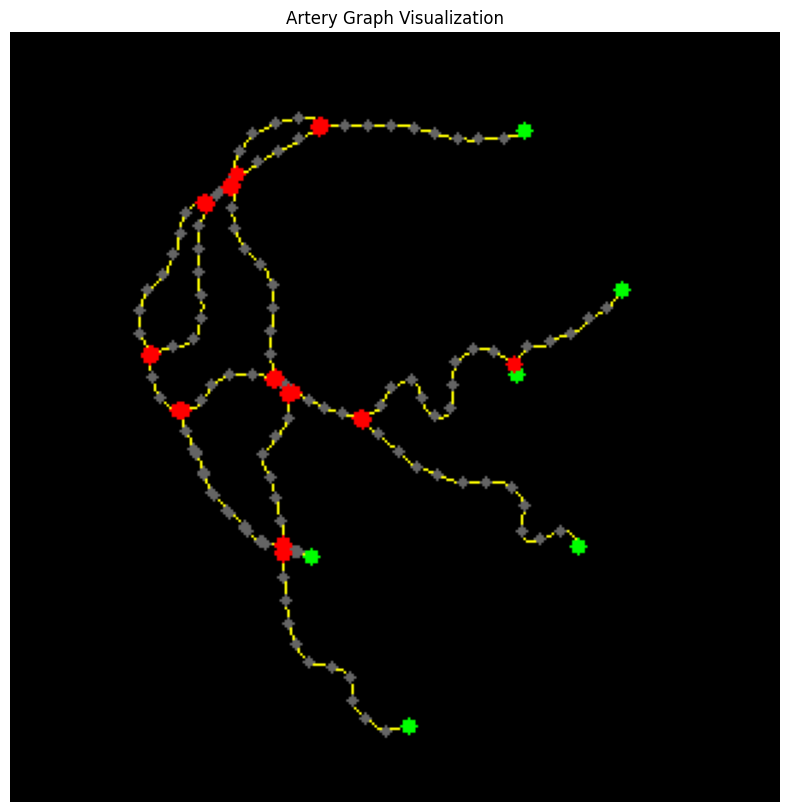

In [3]:
input_path = "./database/11_gt.pgm"
output_path = "artery_graph.json"
spacing = 10

generator = ArteryGraphGenerator(input_path)
generator.save_to_json(output_path, intermediate_node_spacing=spacing)
visualization = generator.visualize_graph("artery_graph_visualization.png", intermediate_node_spacing=spacing)
plt.imshow(visualization)
plt.show()

In [4]:
def create_enhanced_visualization(generator, original_path, output_path):
    """
    Create an enhanced side-by-side visualization showing the original image with the
    graph overlay and the standalone graph visualization.
    
    Parameters:
    generator (ImprovedArteryGraphGenerator): The generator instance
    original_path (str): Path to the original image
    output_path (str): Path to save the visualization
    
    Returns:
    str: Path to the saved visualization, or None if creation failed
    """
    try:
        # Set up the figure with three subfigures
        fig = plt.figure(figsize=(20, 10))
        gs = GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 1])
        
        # Load original image if available
        if original_path and os.path.exists(original_path):
            # Original image
            ax1 = fig.add_subplot(gs[0, 0])
            original_img = cv2.imread(original_path)
            
            # Convert to grayscale if it's a color image
            if len(original_img.shape) == 3:
                original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
                
            ax1.imshow(original_img, cmap='gray')
            ax1.set_title("Original Image")
            ax1.axis('off')
            
            # Overlaid image
            ax2 = fig.add_subplot(gs[0, 1])
            
            # Ensure skeleton is created
            if generator.skeleton is None:
                generator.create_skeleton()
            
            # Create the graph visualization
            vis_img = generator.visualize_graph(output_path=None, node_radius=3)
            
            # Create an overlay of the original image and graph
            overlay_img = create_overlay(original_img, vis_img)
            
            ax2.imshow(overlay_img)
            ax2.set_title("Overlay: Original + Graph")
            ax2.axis('off')
        else:
            ax1 = fig.add_subplot(gs[0, 0])
            ax1.text(0.5, 0.5, "Original Image Not Found", 
                     horizontalalignment='center', verticalalignment='center',
                     transform=ax1.transAxes, fontsize=14)
            ax1.axis('off')
            
            ax2 = fig.add_subplot(gs[0, 1])
            ax2.text(0.5, 0.5, "Overlay Not Available", 
                     horizontalalignment='center', verticalalignment='center',
                     transform=ax2.transAxes, fontsize=14)
            ax2.axis('off')
        
        # Graph visualization only
        ax3 = fig.add_subplot(gs[0, 2])
        
        # If we haven't created the visualization yet, do it now
        if 'vis_img' not in locals():
            if generator.skeleton is None:
                generator.create_skeleton()
            vis_img = generator.visualize_graph(output_path=None, node_radius=3)
        
        ax3.imshow(vis_img)
        ax3.set_title("Graph Visualization")
        ax3.axis('off')
        
        # Add legend
        legend_elements = [
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=(0/255, 255/255, 0/255), 
                      markersize=10, label='Extreme Nodes'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=(255/255, 0/255, 0/255), 
                      markersize=10, label='Bifurcation Nodes'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=(0/255, 0/255, 255/255), 
                      markersize=10, label='Trifurcation Nodes'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=(100/255, 100/255, 100/255), 
                      markersize=10, label='Intermediate Nodes'),
            plt.Line2D([0], [0], color=(255/255, 255/255, 0/255), lw=2, label='Skeleton')
        ]
        
        fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=12)
        plt.tight_layout()
        
        # Adjust layout to make room for the legend
        plt.subplots_adjust(bottom=0.15)
        
        # Save visualization
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        
        print(f"Enhanced visualization saved to {output_path}")
        return output_path
    
    except Exception as e:
        print(f"Error creating enhanced visualization: {str(e)}")
        return None


def create_overlay(original_img, vis_img, alpha=0.7):
    """
    Create an overlay of the original image and the graph visualization.
    
    Parameters:
    original_img (numpy.ndarray): The original grayscale image
    vis_img (numpy.ndarray): The graph visualization image
    alpha (float): Transparency factor for blending (0.0-1.0)
    
    Returns:
    numpy.ndarray: The blended image
    """
    # Convert original grayscale to 3-channel grayscale if needed
    if len(original_img.shape) == 2:
        original_rgb = cv2.cvtColor(original_img, cv2.COLOR_GRAY2RGB)
    else:
        original_rgb = original_img.copy()
    
    # Ensure both images have the same shape
    h1, w1 = original_rgb.shape[:2]
    h2, w2 = vis_img.shape[:2]
    
    if h1 != h2 or w1 != w2:
        # Resize visualization to match original image
        vis_img = cv2.resize(vis_img, (w1, h1), interpolation=cv2.INTER_AREA)
    
    # Create mask for graph elements (non-black pixels)
    # Assuming black (0,0,0) is the background in vis_img
    mask = np.any(vis_img > 10, axis=2)
    
    # Create the overlay image
    overlay = original_rgb.copy()
    
    # For each colored pixel in vis_img, blend it with the original
    overlay[mask] = cv2.addWeighted(
        original_rgb[mask], 1-alpha, 
        vis_img[mask], alpha, 0
    )
    
    return overlay

In [5]:
def create_side_by_side_visualization(generator, original_path, output_path):
    """
    Create a side-by-side visualization showing the original image and the graph visualization.
    
    Parameters:
    generator (ImprovedArteryGraphGenerator): The generator instance
    original_path (str): Path to the original image
    output_path (str): Path to save the visualization
    
    Returns:
    str: Path to the saved visualization, or None if creation failed
    """
    try:
        # Set up the figure with two subfigures
        fig = plt.figure(figsize=(20, 10))
        gs = GridSpec(1, 2, figure=fig)
        
        # Load and display original image if available
        if original_path and os.path.exists(original_path):
            ax1 = fig.add_subplot(gs[0, 0])
            original_img = cv2.imread(original_path)
            
            # Convert to grayscale if it's a color image
            if len(original_img.shape) == 3:
                original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
                
            ax1.imshow(original_img, cmap='gray')
            ax1.set_title("Original Image")
            ax1.axis('off')
        else:
            ax1 = fig.add_subplot(gs[0, 0])
            ax1.text(0.5, 0.5, "Original Image Not Found", 
                     horizontalalignment='center', verticalalignment='center',
                     transform=ax1.transAxes, fontsize=14)
            ax1.axis('off')
        
        # Generate and display graph visualization
        ax2 = fig.add_subplot(gs[0, 1])
        
        # Ensure skeleton is created
        if generator.skeleton is None:
            generator.create_skeleton()
        
        # Generate graph visualization
        vis_img = generator.visualize_graph(output_path=None, node_radius=3)
        
        ax2.imshow(vis_img)
        ax2.set_title("Graph Visualization")
        ax2.axis('off')
        
        # Add legend
        legend_elements = [
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=(0/255, 255/255, 0/255), 
                      markersize=10, label='Extreme Nodes'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=(255/255, 0/255, 0/255), 
                      markersize=10, label='Bifurcation Nodes'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=(0/255, 0/255, 255/255), 
                      markersize=10, label='Trifurcation Nodes'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=(100/255, 100/255, 100/255), 
                      markersize=10, label='Intermediate Nodes'),
            plt.Line2D([0], [0], color=(255/255, 255/255, 0/255), lw=2, label='Skeleton')
        ]
        
        fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=12)
        plt.tight_layout()
        
        # Adjust layout to make room for the legend
        plt.subplots_adjust(bottom=0.15)
        
        # Save visualization
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        
        print(f"Visualization saved to {output_path}")
        return output_path
    
    except Exception as e:
        print(f"Error creating visualization: {str(e)}")
        return None


# Create a combined visualization grid for all processed images
def create_grid_visualization(visualization_paths, output_path, grid_size=None):
    """
    Create a grid visualization of all processed images.
    
    Parameters:
    visualization_paths (list): List of paths to individual visualizations
    output_path (str): Path to save the grid visualization
    grid_size (tuple): Grid size as (rows, cols), if None it will be automatically determined
    
    Returns:
    str: Path to the saved grid visualization
    """
    if not visualization_paths:
        print("No visualizations to create grid from")
        return None
    
    # Determine grid size if not provided
    if grid_size is None:
        num_images = len(visualization_paths)
        cols = min(4, num_images)  # Maximum 4 columns
        rows = (num_images + cols - 1) // cols  # Ceiling division
        grid_size = (rows, cols)
    else:
        rows, cols = grid_size
    
    # Create figure
    fig = plt.figure(figsize=(cols * 6, rows * 4))
    
    # Add visualizations to grid
    for i, vis_path in enumerate(visualization_paths):
        if i >= rows * cols:
            print(f"Warning: Grid size {grid_size} too small for {len(visualization_paths)} images. Truncating.")
            break
        
        # Calculate grid position
        row = i // cols
        col = i % cols
        
        # Create subplot
        ax = fig.add_subplot(rows, cols, i + 1)
        
        # Load and display image
        try:
            img = plt.imread(vis_path)
            ax.imshow(img)
            
            # Extract file name for title
            file_name = os.path.basename(vis_path).replace("_visualization.png", "")
            ax.set_title(file_name, fontsize=10)
            ax.axis('off')
            
        except Exception as e:
            print(f"Error loading image {vis_path}: {str(e)}")
            ax.text(0.5, 0.5, "Error loading image", 
                    horizontalalignment='center', verticalalignment='center',
                    transform=ax.transAxes, fontsize=10)
            ax.axis('off')
    
    # Adjust layout
    plt.tight_layout()
    
    # Save visualization
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    
    print(f"Grid visualization saved to {output_path}")
    return output_path

In [6]:
def process_pgm_files(folder_path, output_folder=None, pattern="*_gt.pgm", intermediate_node_spacing=5, use_enhanced_visualization=True):
    """
    Process all PGM files in a folder that match a specific pattern.
    Generate and visualize graphs for each file.
    
    Parameters:
    folder_path (str): Path to the folder containing PGM files
    output_folder (str): Path to save outputs (defaults to folder_path/results if None)
    pattern (str): File pattern to match (default: "*_gt.pgm")
    intermediate_node_spacing (int): Spacing for intermediate nodes
    use_enhanced_visualization (bool): Whether to use the enhanced visualization with overlay
    
    Returns:
    list: Paths to all generated visualizations
    """
    # Create output folder if it doesn't exist
    if output_folder is None:
        output_folder = os.path.join(folder_path, "results")
    
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        print(f"Created output directory: {output_folder}")
    
    # Find all files matching the pattern
    file_pattern = os.path.join(folder_path, pattern)
    matching_files = glob.glob(file_pattern)
    
    if not matching_files:
        print(f"No files found matching pattern '{pattern}' in {folder_path}")
        return []
    
    print(f"Found {len(matching_files)} files matching pattern '{pattern}'")
    
    # Process each file
    visualization_paths = []
    
    for file_path in matching_files:
        file_name = os.path.basename(file_path)
        base_name = os.path.splitext(file_name)[0]
        
        # Find original image (remove _gt suffix)
        original_name = base_name.replace("_gt", "")
        original_path = os.path.join(folder_path, f"{original_name}.pgm")
        
        # Check if original image exists
        if not os.path.exists(original_path):
            print(f"Original image not found for {file_name}. Trying alternative extensions...")
            # Try other common extensions
            for ext in ['.tif', '.tiff', '.png', '.jpg', '.jpeg']:
                alt_path = os.path.join(folder_path, f"{original_name}{ext}")
                if os.path.exists(alt_path):
                    original_path = alt_path
                    print(f"Found original image: {alt_path}")
                    break
            else:
                print(f"WARNING: Could not find original image for {file_name}, skipping visualization")
                original_path = None
        
        # Output paths
        json_output = os.path.join(output_folder, f"{base_name}_graph.json")
        vis_output = os.path.join(output_folder, f"{base_name}_visualization.png")
        
        print(f"Processing {file_path}...")
        
        # Create graph generator
        generator = ArteryGraphGenerator(file_path)
        
        # Generate graph and save to JSON
        generator.save_to_json(json_output, intermediate_node_spacing=intermediate_node_spacing)
        
        # Create visualization
        if use_enhanced_visualization:
            visualization_path = create_enhanced_visualization(
                generator, 
                original_path, 
                vis_output
            )
        else:
            visualization_path = create_side_by_side_visualization(
                generator, 
                original_path, 
                vis_output
            )
        
        if visualization_path:
            visualization_paths.append(visualization_path)
    
    print(f"Processing complete. Generated {len(visualization_paths)} visualizations.")
    return visualization_paths

Found 20 files matching pattern '*_gt.pgm'
Processing ./database/13_gt.pgm...
Graph saved to output/13_gt_graph.json
Total nodes: 191
Extreme nodes: 5
Bifurcation nodes: 19
Trifurcation nodes: 0
Intermediate nodes: 167
Edges (vessel segments): 1848
Enhanced visualization saved to output/13_gt_visualization.png
Processing ./database/01_gt.pgm...
Graph saved to output/01_gt_graph.json
Total nodes: 203
Extreme nodes: 6
Bifurcation nodes: 21
Trifurcation nodes: 1
Intermediate nodes: 175
Edges (vessel segments): 3569
Enhanced visualization saved to output/01_gt_visualization.png
Processing ./database/03_gt.pgm...
Graph saved to output/03_gt_graph.json
Total nodes: 199
Extreme nodes: 5
Bifurcation nodes: 11
Trifurcation nodes: 0
Intermediate nodes: 183
Edges (vessel segments): 188
Enhanced visualization saved to output/03_gt_visualization.png
Processing ./database/11_gt.pgm...
Graph saved to output/11_gt_graph.json
Total nodes: 279
Extreme nodes: 6
Bifurcation nodes: 30
Trifurcation nodes: 0

/var/folders/2s/j3vn9g1d48b630yqb51x1d740000gn/T/ipykernel_76630/3459193384.py:526: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 10))
/var/folders/2s/j3vn9g1d48b630yqb51x1d740000gn/T/ipykernel_76630/3415651180.py:109: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(cols * 6, rows * 4))


Grid visualization saved to all_visualizations.png


'all_visualizations.png'

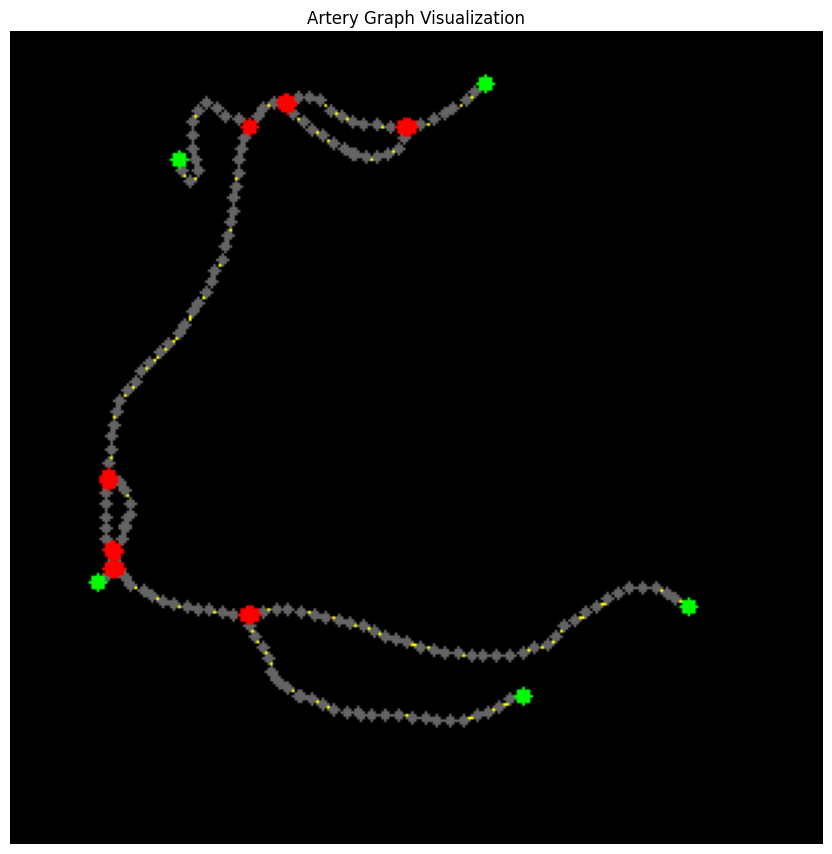

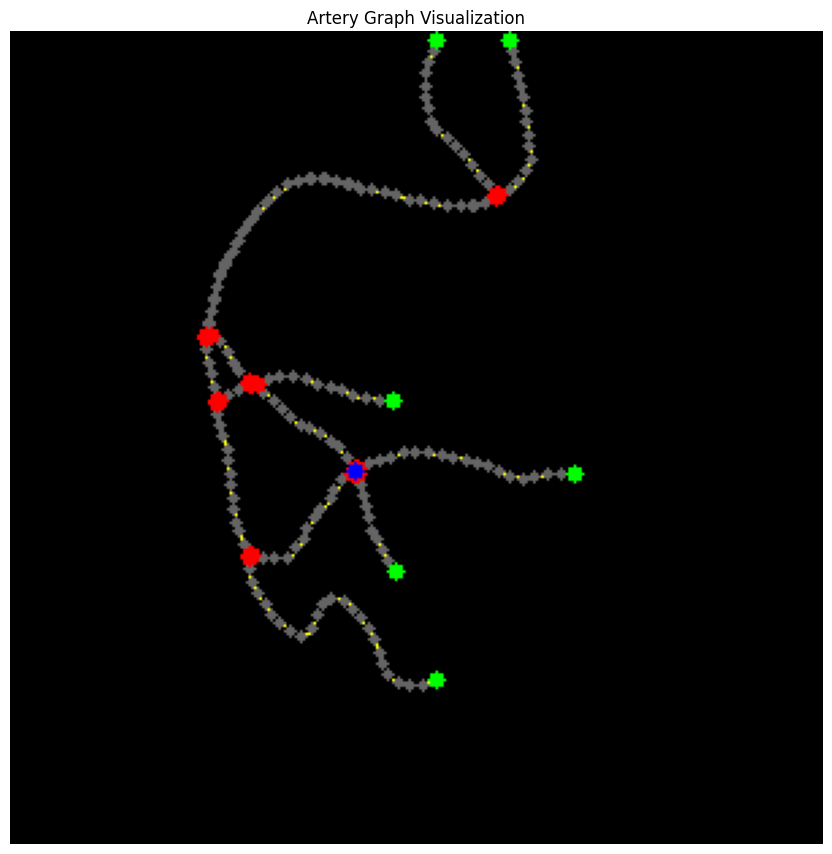

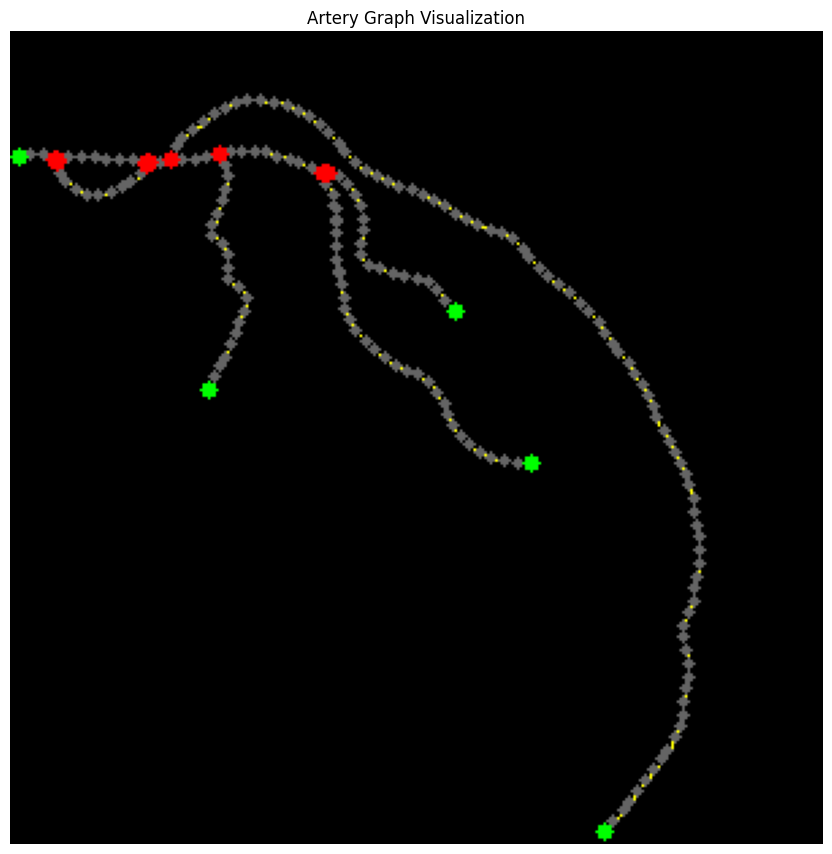

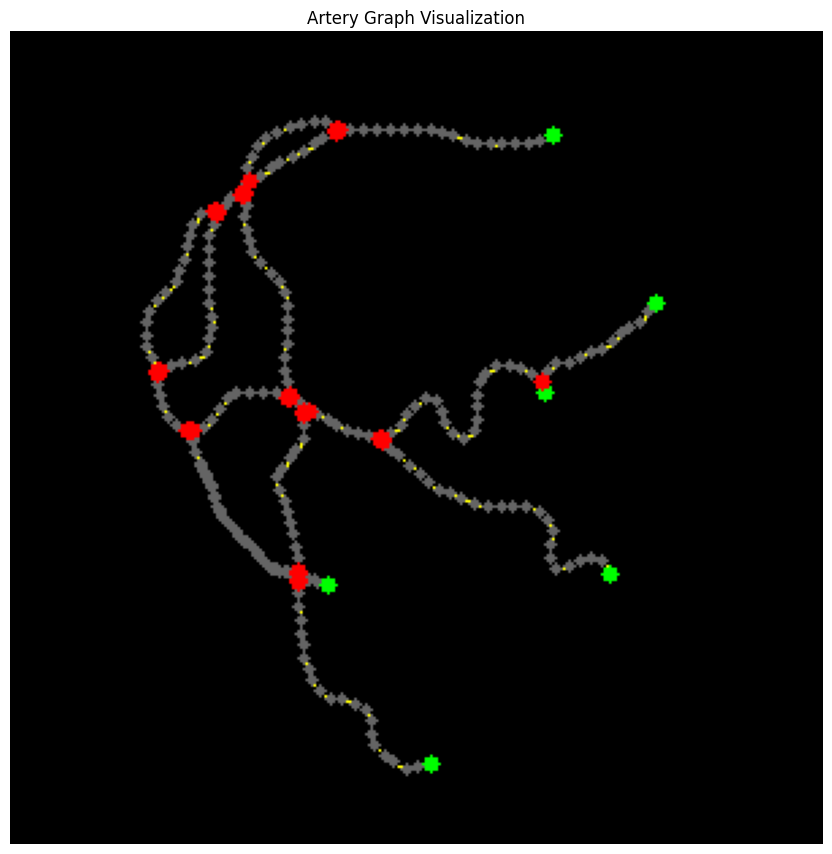

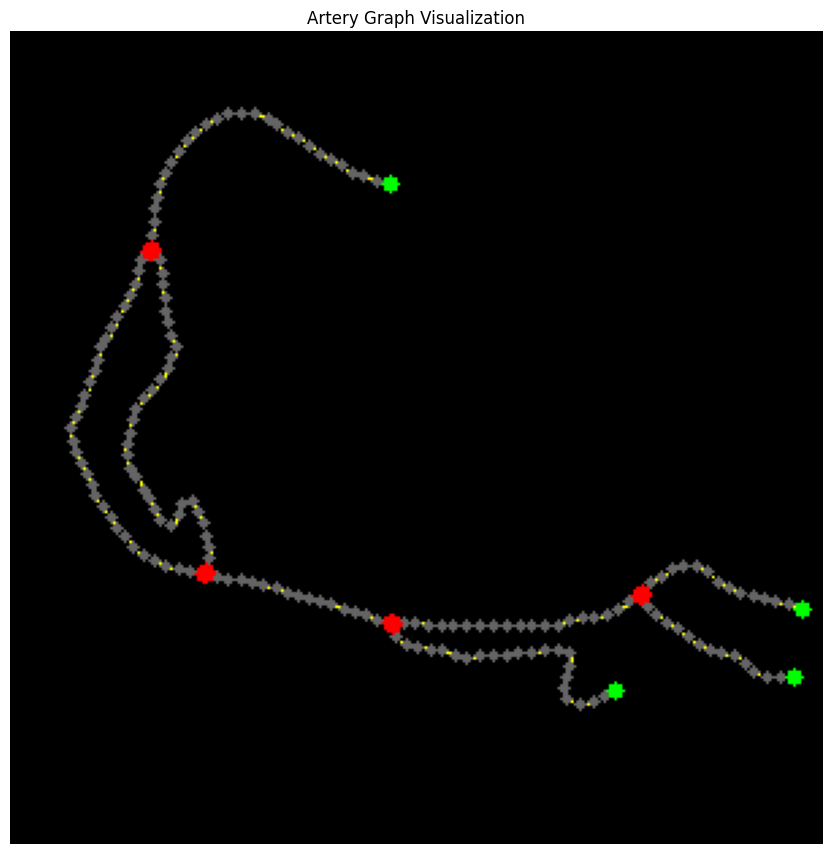

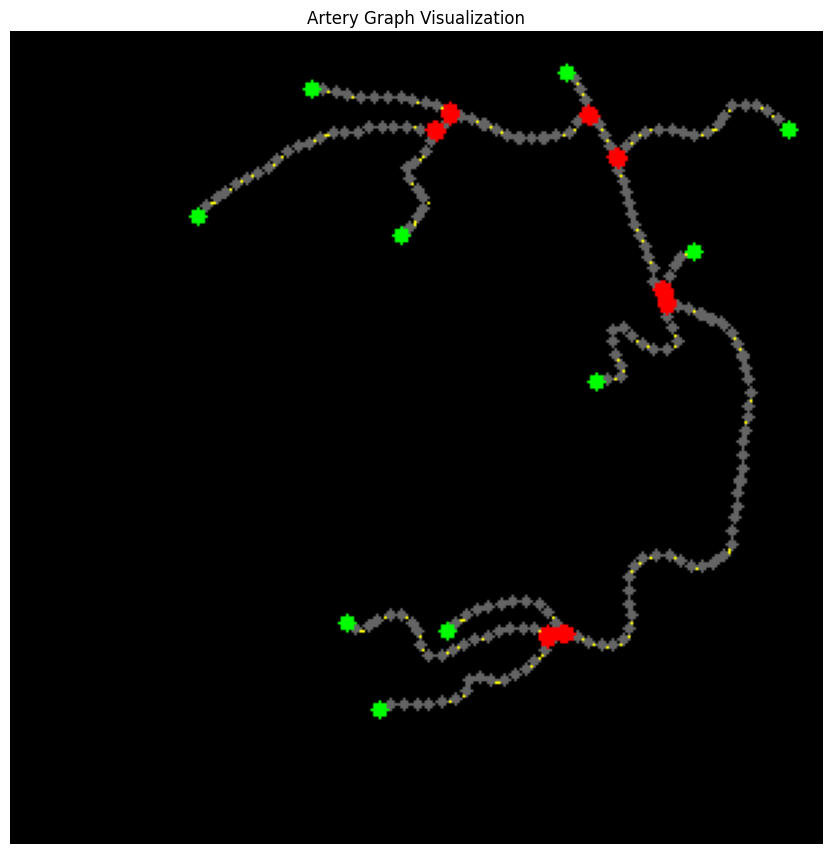

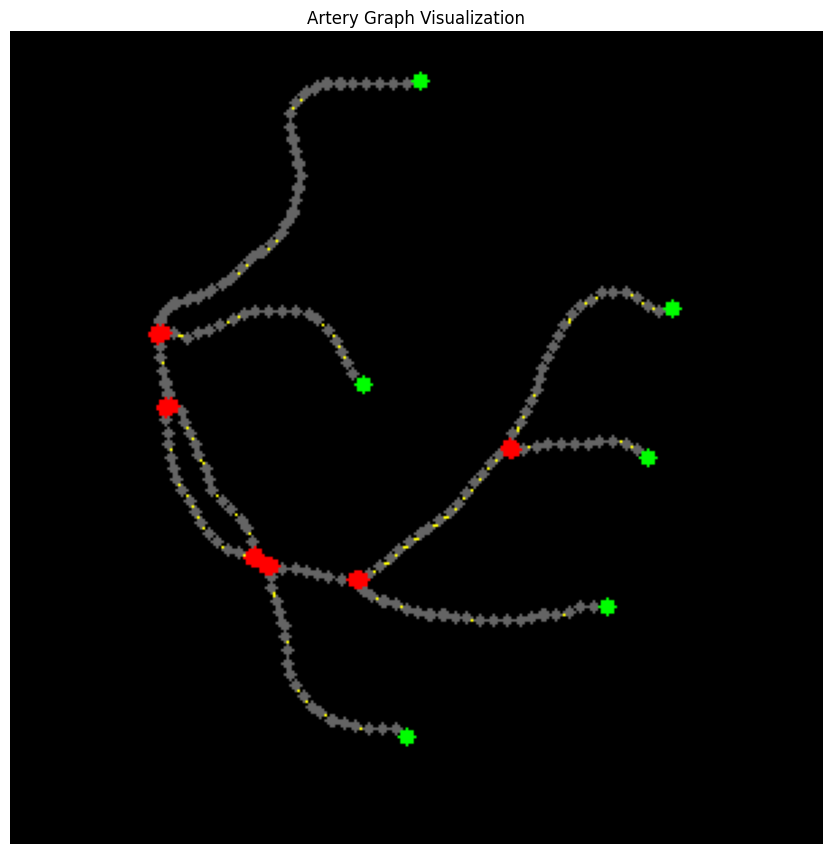

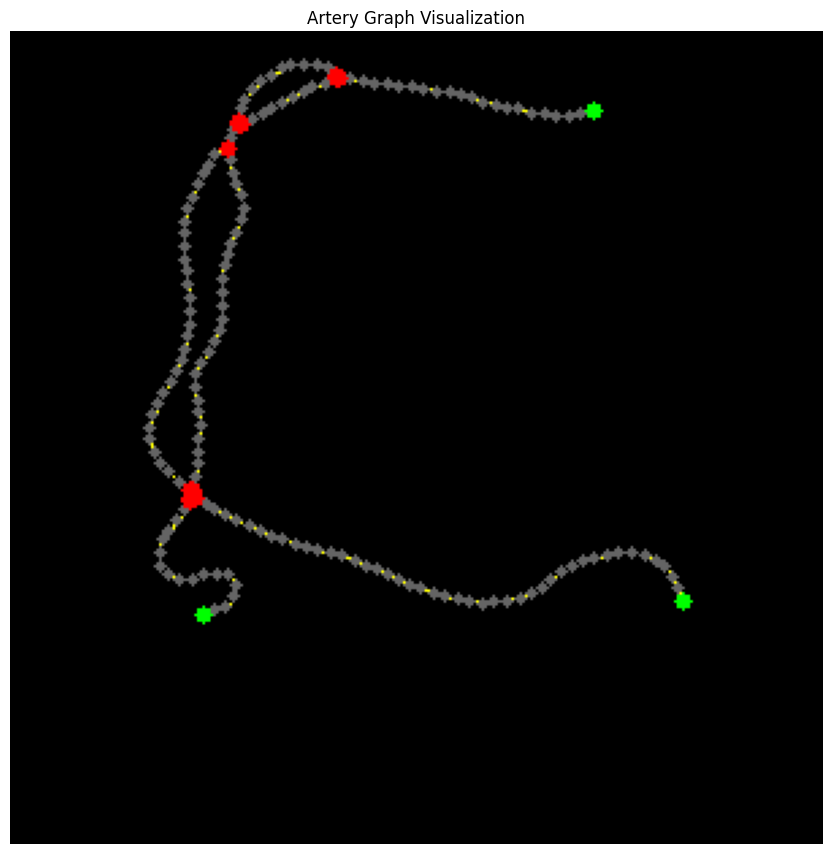

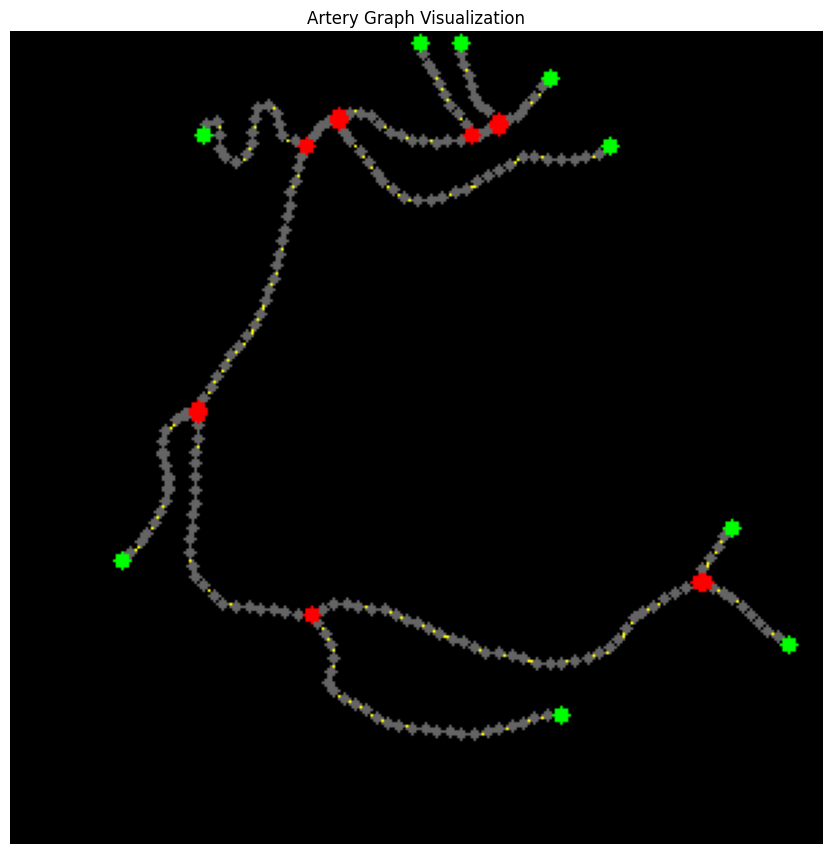

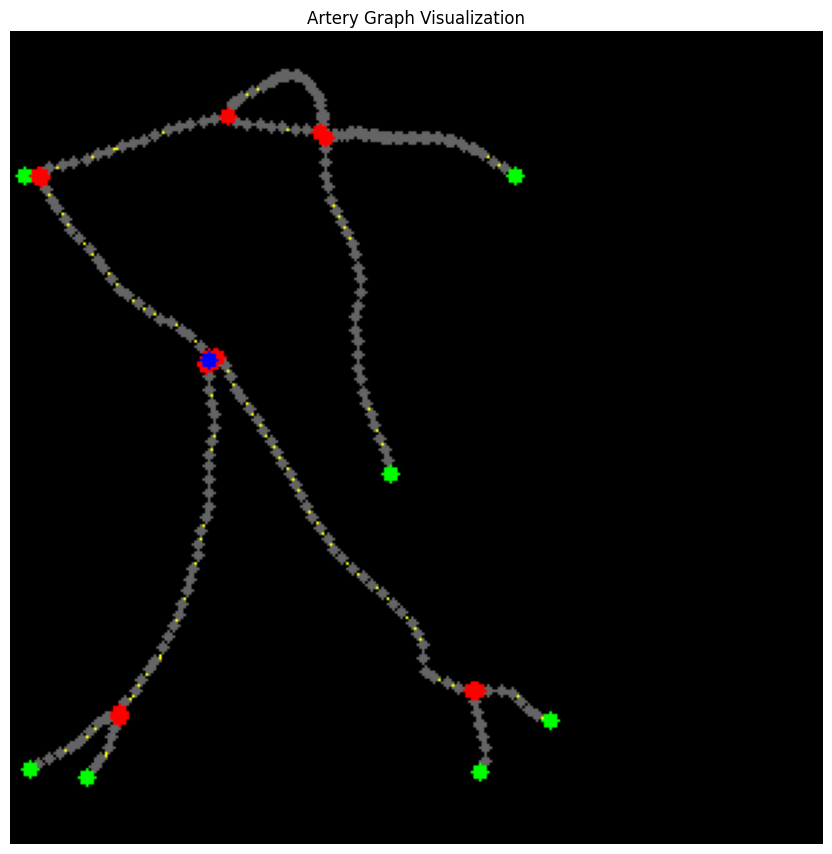

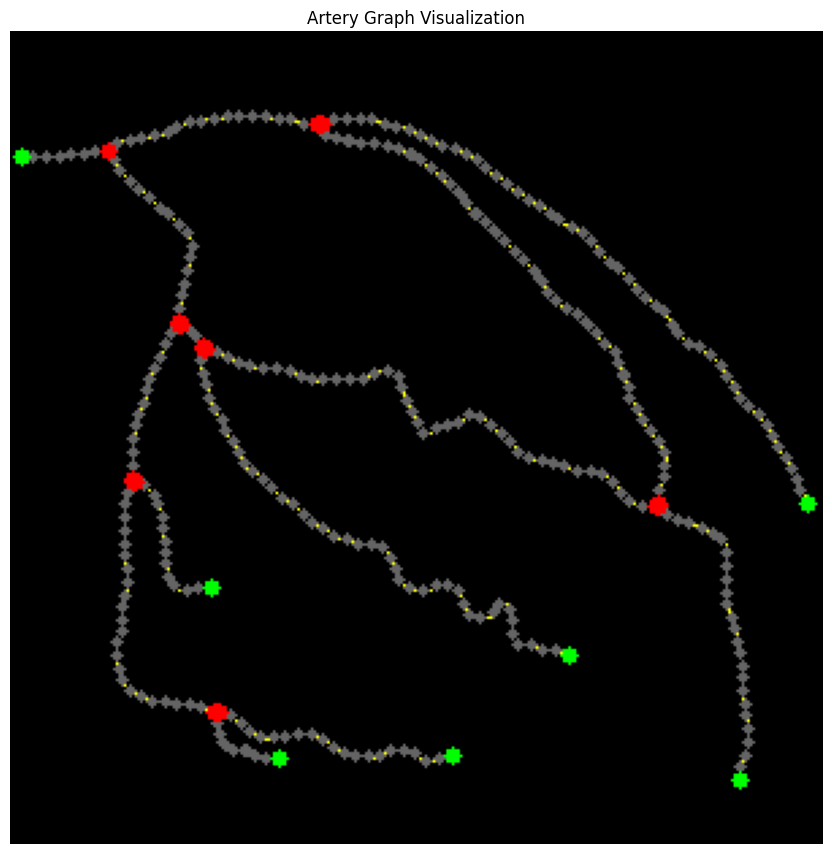

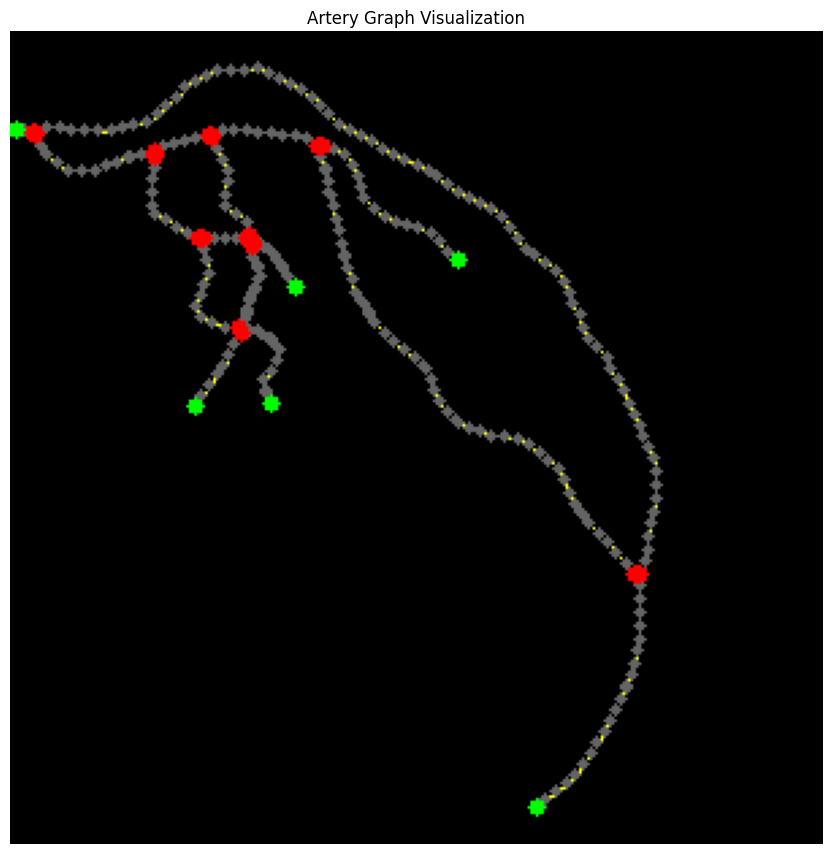

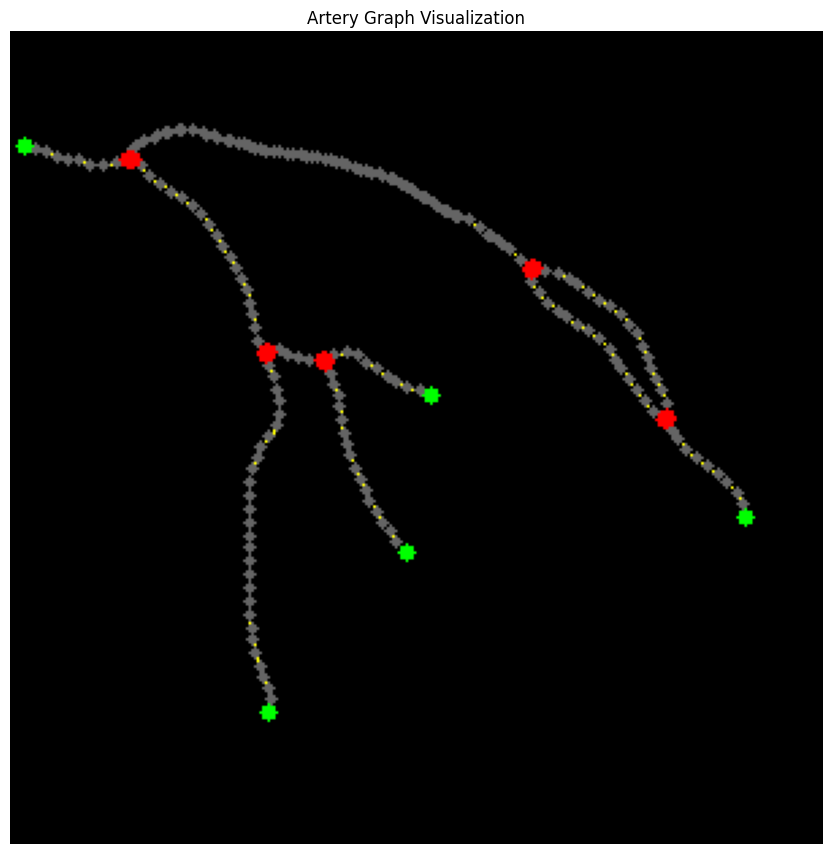

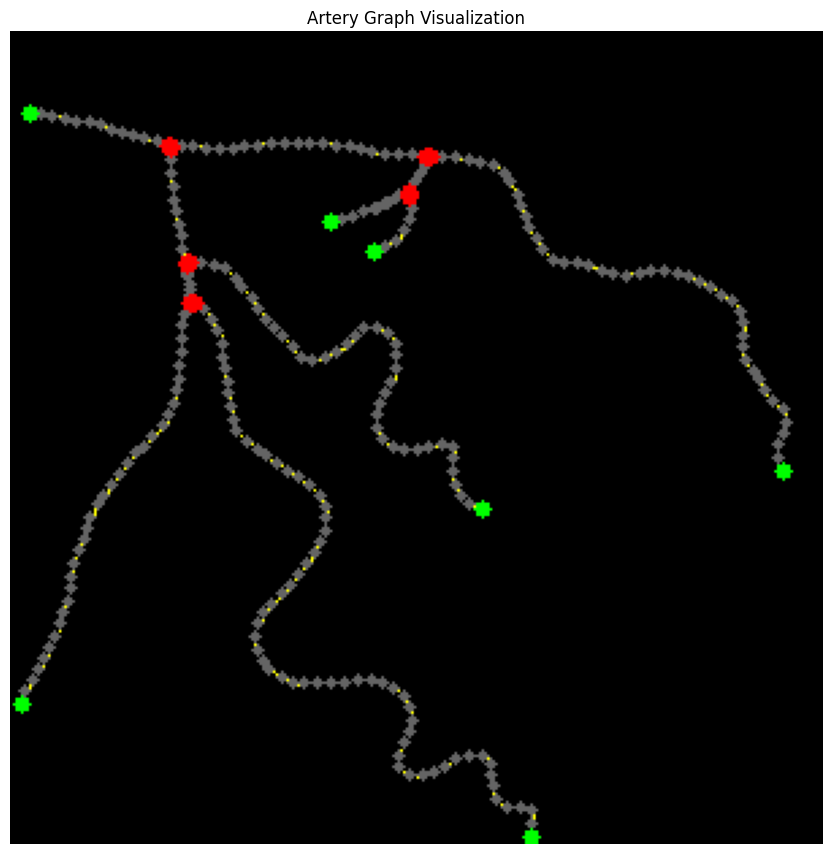

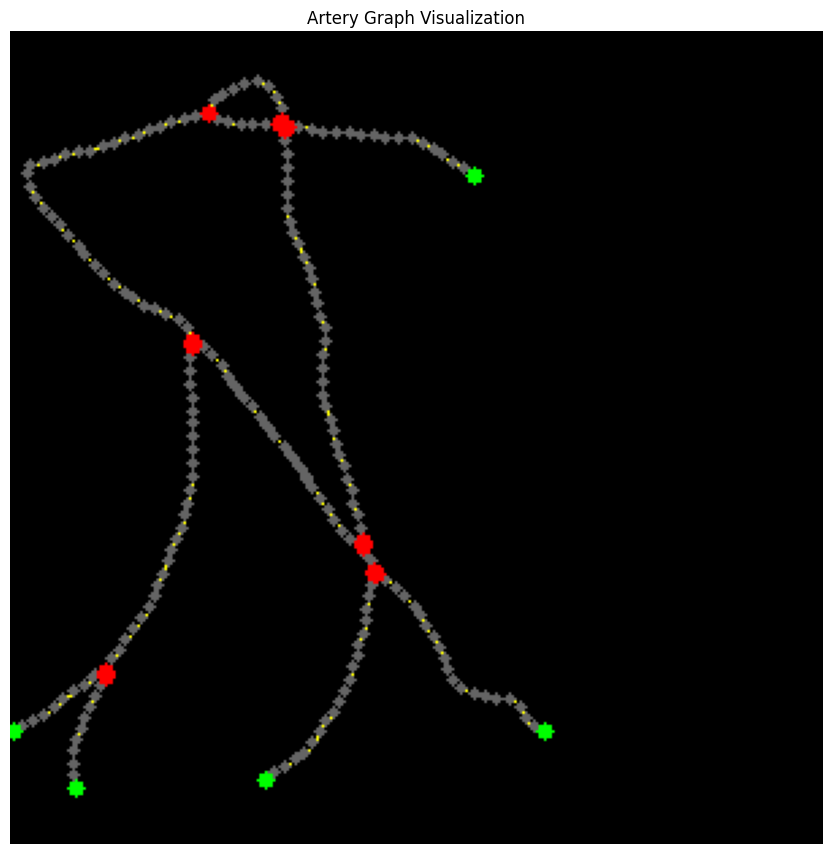

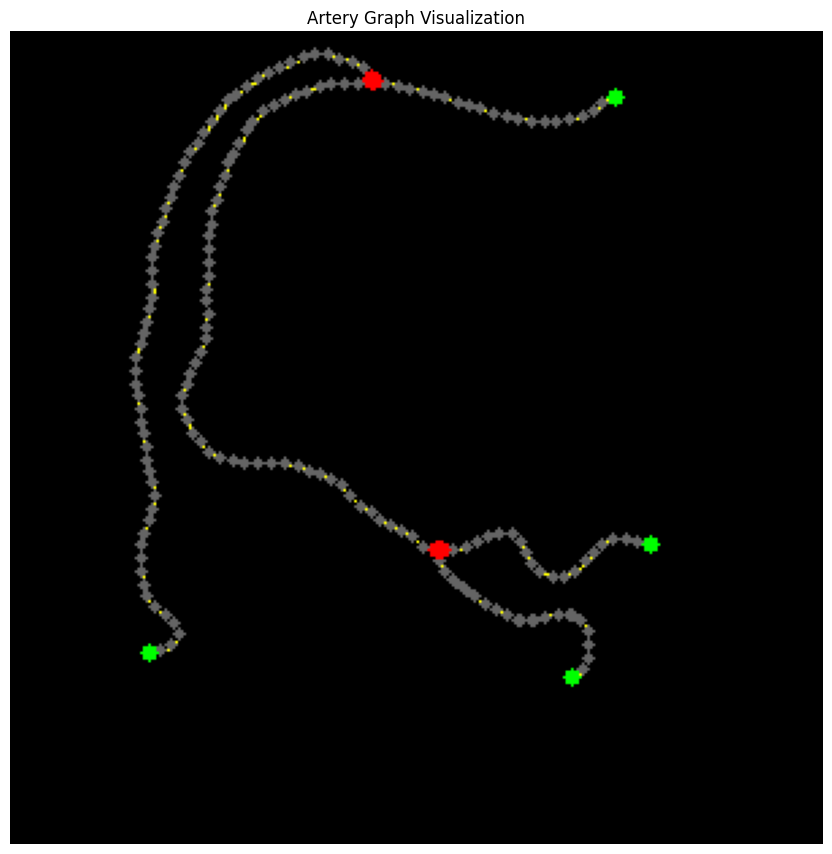

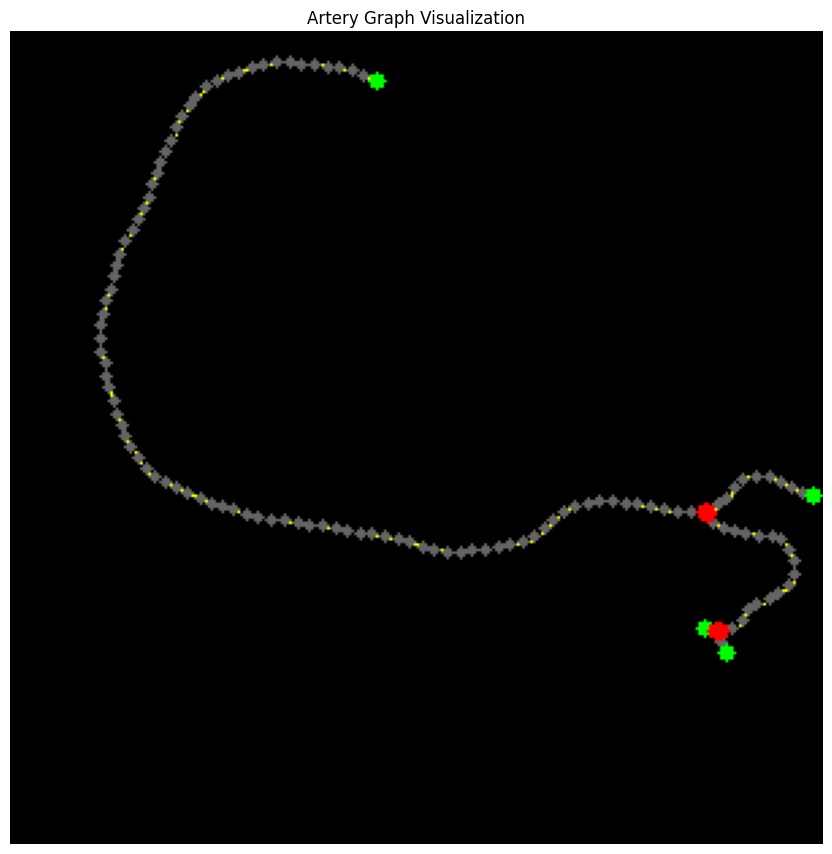

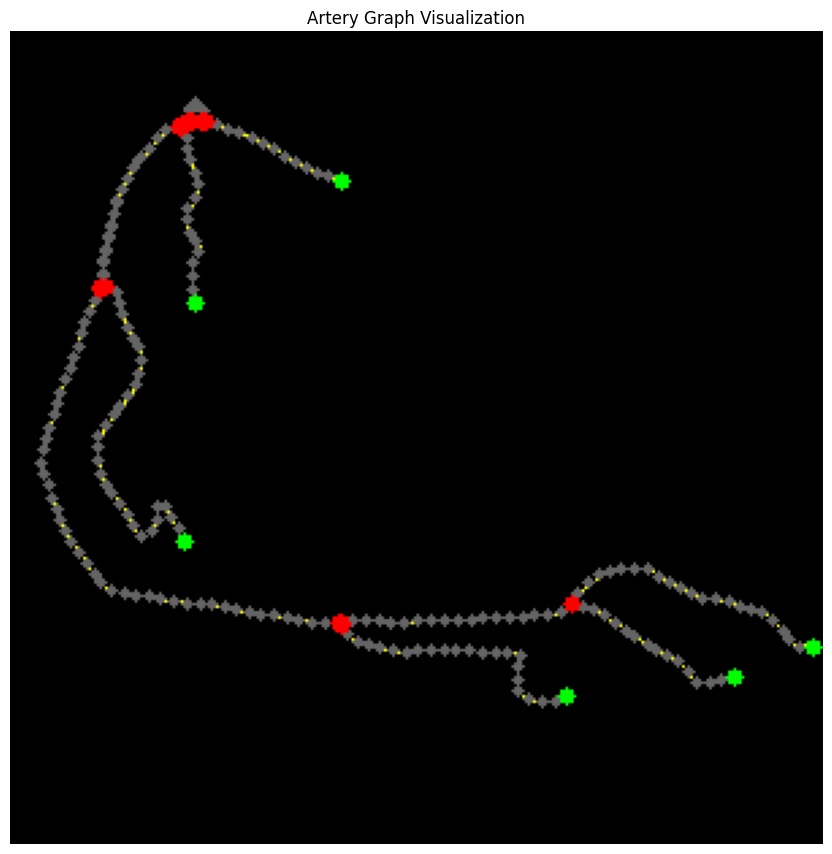

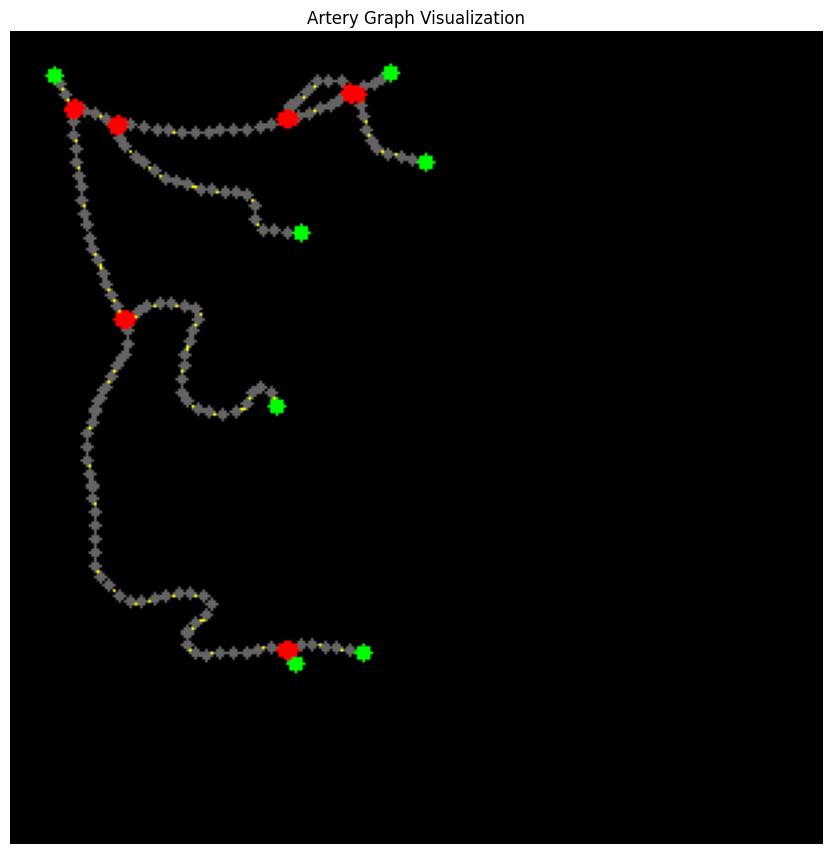

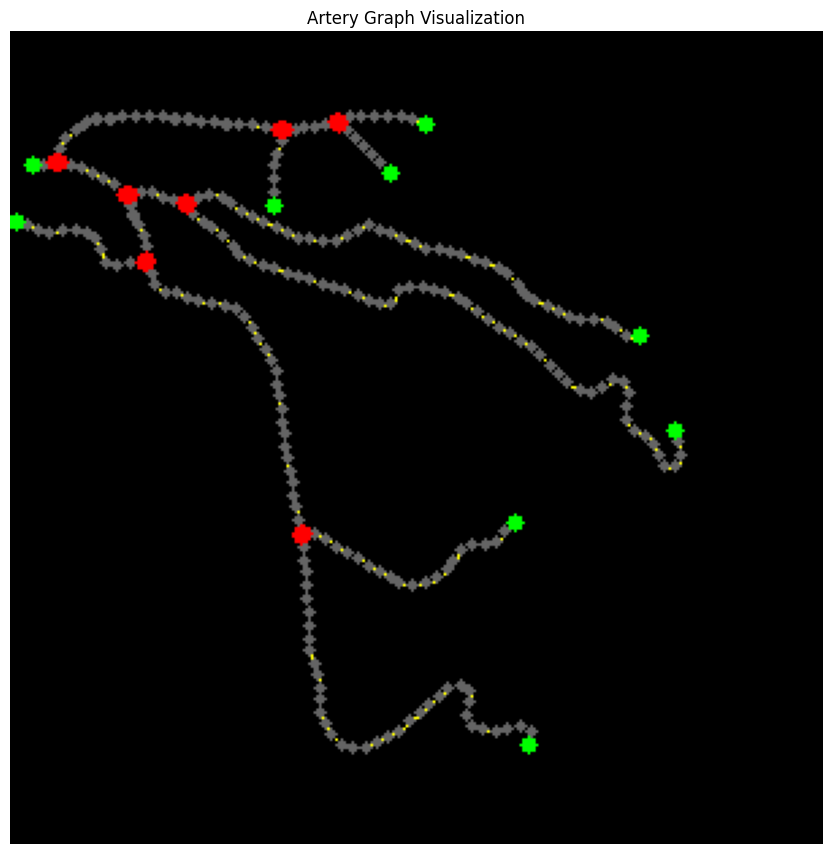

In [7]:
# Process all *_gt.pgm files in a folder
visualization_paths = process_pgm_files(
    './database',
    output_folder='output',
    pattern='*_gt.pgm',
    intermediate_node_spacing=20
)

# Create a grid visualization of all results
create_grid_visualization(
    visualization_paths,
    'all_visualizations.png'
)